In [70]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from scipy.stats import laplace

# Setting up the data and initial exploration

In [71]:
# loading a real world data
data = load_breast_cancer(as_frame=True)
df = data.frame
print(df.head)

<bound method NDFrame.head of      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean conca

I am trying to isolate the malignant one because I want to see what effect will adding privacy constant have on actual breast cancer statistic which are positive

In [72]:
features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']
df_malignant = df[df['target'] == 0][features]
num_of_patients = len(df_malignant)

In [73]:
print(df_malignant.head)
print('Number of patients who have malignant tumor:' , num_of_patients)

<bound method NDFrame.head of      mean radius  mean texture  mean perimeter  mean area  mean smoothness
0          17.99         10.38          122.80     1001.0          0.11840
1          20.57         17.77          132.90     1326.0          0.08474
2          19.69         21.25          130.00     1203.0          0.10960
3          11.42         20.38           77.58      386.1          0.14250
4          20.29         14.34          135.10     1297.0          0.10030
..           ...           ...             ...        ...              ...
563        20.92         25.09          143.00     1347.0          0.10990
564        21.56         22.39          142.00     1479.0          0.11100
565        20.13         28.25          131.20     1261.0          0.09780
566        16.60         28.08          108.30      858.1          0.08455
567        20.60         29.33          140.10     1265.0          0.11780

[212 rows x 5 columns]>
Number of patients who have malignant tumor: 

# Setting up data boundaries for Differential Privacy (DP)
- to calculate the global sensitivity, global boundaries must be set
- data boundaries `[Min, Max]` 
- we can't just use the `df.min()` and `df.max()` method to find the minimun and maximum boundaries becasue this can leak data
- so we can use the metadata from the dataset to setup the boundaries

For this project the boundaries were taken straight from the official Wisconsin Diagnostic Breast Cancer (WDBC) metadata and they were rounded up for easier calculations

In [74]:
from ucimlrepo import fetch_ucirepo 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
X = breast_cancer_wisconsin_diagnostic.data.features 
summary_stats = X.describe().loc[['min', 'max']]
# Assuming your summary DataFrame is named 'summary'
target_features = ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1']
summary = summary_stats[target_features]

# Rename columns to match your exact requested labels
summary.columns = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

print(summary)


     mean radius  mean texture  mean perimeter  mean area  mean smoothness
min        6.981          9.71           43.79      143.5          0.05263
max       28.110         39.28          188.50     2501.0          0.16340


# Choosing the upper and lower bound
- To cap the absolute max (Enfored Upper Bound), i chose to round it up to the next logical clean number to prevent the boundary limit themselves from leaking the individual traits
- For the absolute min the lower bound is zero for convenience and simplicity

| Feature Name     | Empirical Minimum | Empirical Maximum | Enforced DP Lower Bound | Enforced DP Upper Bound |
|-------------------|--------------------|--------------------|---------------------------|---------------------------|
| mean radius       | 6.98 mm            | 28.11 mm           | 0                          | 40.0 mm                   |
| mean texture       | 9.71               | 39.28              | 0                          | 50.0                       |
| mean perimeter     | 43.79 mm           | 188.50 mm          | 0                          | 250.0 mm                  |
| mean area          | 143.50 mm²         | 2501.00 mm²        | 0                          | 3000.0 mm²                |
| mean smoothness    | 0.05               | 0.16               | 0                          | 0.25                       |

**Sensitivity** represent the maximum amount of deviation in output statistical query that is caused by the addition or removal of any single individual's data

**General Formula for Global Sensitivity**

Δf = max‖f(D) − f(D′)‖

**Breakdown:**

- **Δf** — the global sensitivity of function *f*
- **f(D)** — the output of query/function *f* on dataset *D*
- **f(D′)** — the output of the same function on a neighboring dataset *D′* (differs from *D* by exactly one record — one addition, removal, or change)
- **‖ · ‖** — a norm (commonly the L1 or L2 norm), measuring the "distance" between the two outputs
- **max** — taken over **all possible neighboring dataset pairs** (D, D′) — sensitivity is the worst-case change, not the average case

**Intuition:** it answers *"If one person's data is added, removed, or changed, how much can the query's output possibly shift?"* This worst-case shift is what determines how much noise must be added to preserve privacy.


──────────────────────────────────────────────────────────────────────────────────────────

**Epsilon** represent the privacy budget that control how much privacy we want to enforce
Low epsilon means higher privacy and higher epsilon means lower privacy

**Noise** represent the statistical randomness that is added to the output of a query to hide individual record identities

It is the ratio of the sensitivity and epsilon

Noise = sensitivity / epsilon

──────────────────────────────────────────────────────────────────────────────────────────


[ High Sensitivity ] (Wide Data Range)  ┐
                                       
                                       
                                        ├─► [ MASSIVE NOISE ADDED ] ──► (Low Data Accuracy)

[ Low Epsilon Budget ] (Strict Privacy) ┘

──────────────────────────────────────────────────────────────────────────────────────────

[ Low Sensitivity ] (Tight Data Range)  ┐
                                        
                                        ├─► [ TINY NOISE ADDED ] ────► (High Data Accuracy)

[ High Epsilon Budget ] (Loose Privacy) ┘

In [75]:
# setting up boundaries and privacy budget
boundaries = {
    'mean radius':     (0.0, 40.0),    
    'mean texture':    (0.0, 50.0),    
    'mean perimeter':  (0.0, 250.0),   
    'mean area':       (0.0, 3000.0),  
    'mean smoothness': (0.0, 0.25)  
}

# Privacy budget for the analysis
total_epsilon = 1.0

# statistic query we are gonna calculate 
stat_query = ['Mean', 'Std Dev', 'Q1 (25th Pct)', 'Q2 (Median)', 'Q3 (75th Pct)']

- For the five feature, the 5 basic statistics (Mean, Standard Deviation, first quartile, Second Quartile(median) and Third Quartile) are calculated normally
- Again same metrics are measured after adding noise (sensitivity /epsilon) on the data 
- We also divide the privacy budget evenly among each query --> sequential composite theorem
- the noise is calculated by the diffprivlib tools such as `dp.mean` and `dp.std` which has a parameter to enter the bounds and then these bounda re used to calculate the sensitivity by the library
- the difference is then plotted

**Note:** 
<u>Sequential Composite Theorem</u> tells us that every single query we do on the data leaks a bit of privacy and it all adds up linearly 

total privacy budget (total_epsilon) = epsilon_for_query1 + epsilon_for_quety2 + ... + epsilon_for_queryN


In [76]:
no_of_query = len(features) * len(stat_query) # 25 query becasue we have 5 features and 5 query to be performed on each feature

epsilon_per_query = total_epsilon / no_of_query

print(f"Total Records (Malignant):         {len(df_malignant)}")
print(f"Global Privacy Budget (ε):         {total_epsilon}")
print(f"Total Number Of Queries:           {no_of_query}")
print(f"Epsilon Used Per Query:        {epsilon_per_query:.3f}")

Total Records (Malignant):         212
Global Privacy Budget (ε):         1.0
Total Number Of Queries:           25
Epsilon Used Per Query:        0.040


In [77]:
# keeping track of the base result, the result with Differential privacy applied and the deviations
base_results = {}
dp_results = {}
deviations ={}

In [78]:
for col in features:
    raw_data = df_malignant[col].values
    min_bound, max_bound = boundaries[col]
    # enforcing the clipping bound on the data
    data = np.clip(raw_data, min_bound, max_bound)

    # baseline statistics ---> no diffential priacy used
    # done using simply the numpy package

    base_mean = np.mean(data)
    base_std = np.std(data)
    base_q1 = np.percentile(data, 25)
    base_median = np.percentile(data, 50)
    base_q3 = np.percentile(data,75)

    base_results[col] = [base_mean, base_std, base_q1, base_median, base_q3]

    # computing the differential privacy statistics
    # noise added using the laplacian

    # mean sensitivity
    mean_sensitivity = (max_bound - min_bound) / num_of_patients

    # adding noise to mean
    dp_mean = base_mean + np.random.laplace(0, mean_sensitivity / epsilon_per_query)


    # std sensitivity
    std_sensitivity = (max_bound - min_bound) / np.sqrt(num_of_patients)

    # adding noise to the standard deviation
    dp_std = base_std + np.random.laplace(0, std_sensitivity / epsilon_per_query)
   

    # percentile sensitivity
    percentile_sensitivity = (max_bound - min_bound) / (num_of_patients + 1)
    dp_q1 = base_q1 + np.random.laplace(0 , percentile_sensitivity / epsilon_per_query)
    dp_median = base_median + np.random.laplace(0 , percentile_sensitivity / epsilon_per_query)
    dp_q3 = base_q3 + np.random.laplace(0 , percentile_sensitivity / epsilon_per_query)

    # mathematically Q1 < Q2 < Q3
    # adding random noise can mess the order of this
    # we sort the result of applying noise in ascending order
    # then we assign it to Q1, Q2, Q3 based on how smalll or big the value is
    percentiles_sorted = sorted([dp_q1, dp_median, dp_q3])
    dp_q1     = percentiles_sorted[0] # get lowest
    dp_median = percentiles_sorted[1] # get middle
    dp_q3     = percentiles_sorted[2] # get highest

    ######################################################################################################################################################################################
    # post processing
    # since the laplace function uses random values and it does not know the mathematical constraints, the bound are being set for all the stat

    # the mean must fall within the absolute boundary of the data
    dp_mean = max(min_bound, min(max_bound, dp_mean))

    # standard deviation is never less than 0 because it ranges from 0 to infinity we make sure that our dp_std will never be less than 0
    dp_std = max(0.0, dp_std)

    # q1 can't be less than the absolute minimum
    dp_q1 = max(min_bound, dp_q1)

    # q3 can't be more than the absolute maximum
    dp_q3 = min(max_bound, dp_q3)

    dp_results[col] = [dp_mean, dp_std, dp_q1, dp_median, dp_q3]


    # calculating the deviaions between the normal baseline statistic and differential privacy one
    normal_stat = [base_mean, base_std, base_q1, base_median, base_q3]
    dp_stat = [dp_mean, dp_std, dp_q1, dp_median, dp_q3]

    deviation = []

    for normal_value, dp_value in zip(normal_stat, dp_stat):
        absolute_delta = abs(normal_value - dp_value)

        if normal_value != 0:
            percentage_delta = (absolute_delta / normal_value) * 100
        else:
            percentage_delta = 0
        
        deviation.append(percentage_delta)
    
    deviations[col] = deviation
    


In [79]:
# using pandas we create dataframe tables for the base and the dp 

df_base_table = pd.DataFrame(base_results, index =stat_query).round(3)
df_dp_table = pd.DataFrame(dp_results, index =stat_query).round(3)

In [80]:
print("==================================================================")
print("TABLE 1: NORMAL BIOMETRIC PROFILE BASelines")
print("==================================================================")
print(df_base_table)
print("\n==================================================================")
print("TABLE 2: DIFFERENTIALLY PRIVATE CLINICAL PROFILE (NEW METRICS)")
print("==================================================================")
print(df_dp_table)
print("\n")

TABLE 1: NORMAL BIOMETRIC PROFILE BASelines
               mean radius  mean texture  mean perimeter  mean area  \
Mean                17.463        21.605         115.365    978.376   
Std Dev              3.196         3.771          21.803    367.069   
Q1 (25th Pct)       15.075        19.328          98.745    705.300   
Q2 (Median)         17.325        21.460         114.200    932.000   
Q3 (75th Pct)       19.590        23.765         129.925   1203.750   

               mean smoothness  
Mean                     0.103  
Std Dev                  0.013  
Q1 (25th Pct)            0.094  
Q2 (Median)              0.102  
Q3 (75th Pct)            0.111  

TABLE 2: DIFFERENTIALLY PRIVATE CLINICAL PROFILE (NEW METRICS)
               mean radius  mean texture  mean perimeter  mean area  \
Mean                20.263        29.061         143.149      0.000   
Std Dev              0.000        90.787         386.585    191.692   
Q1 (25th Pct)       13.023         8.368          52.6

## Data Visualization

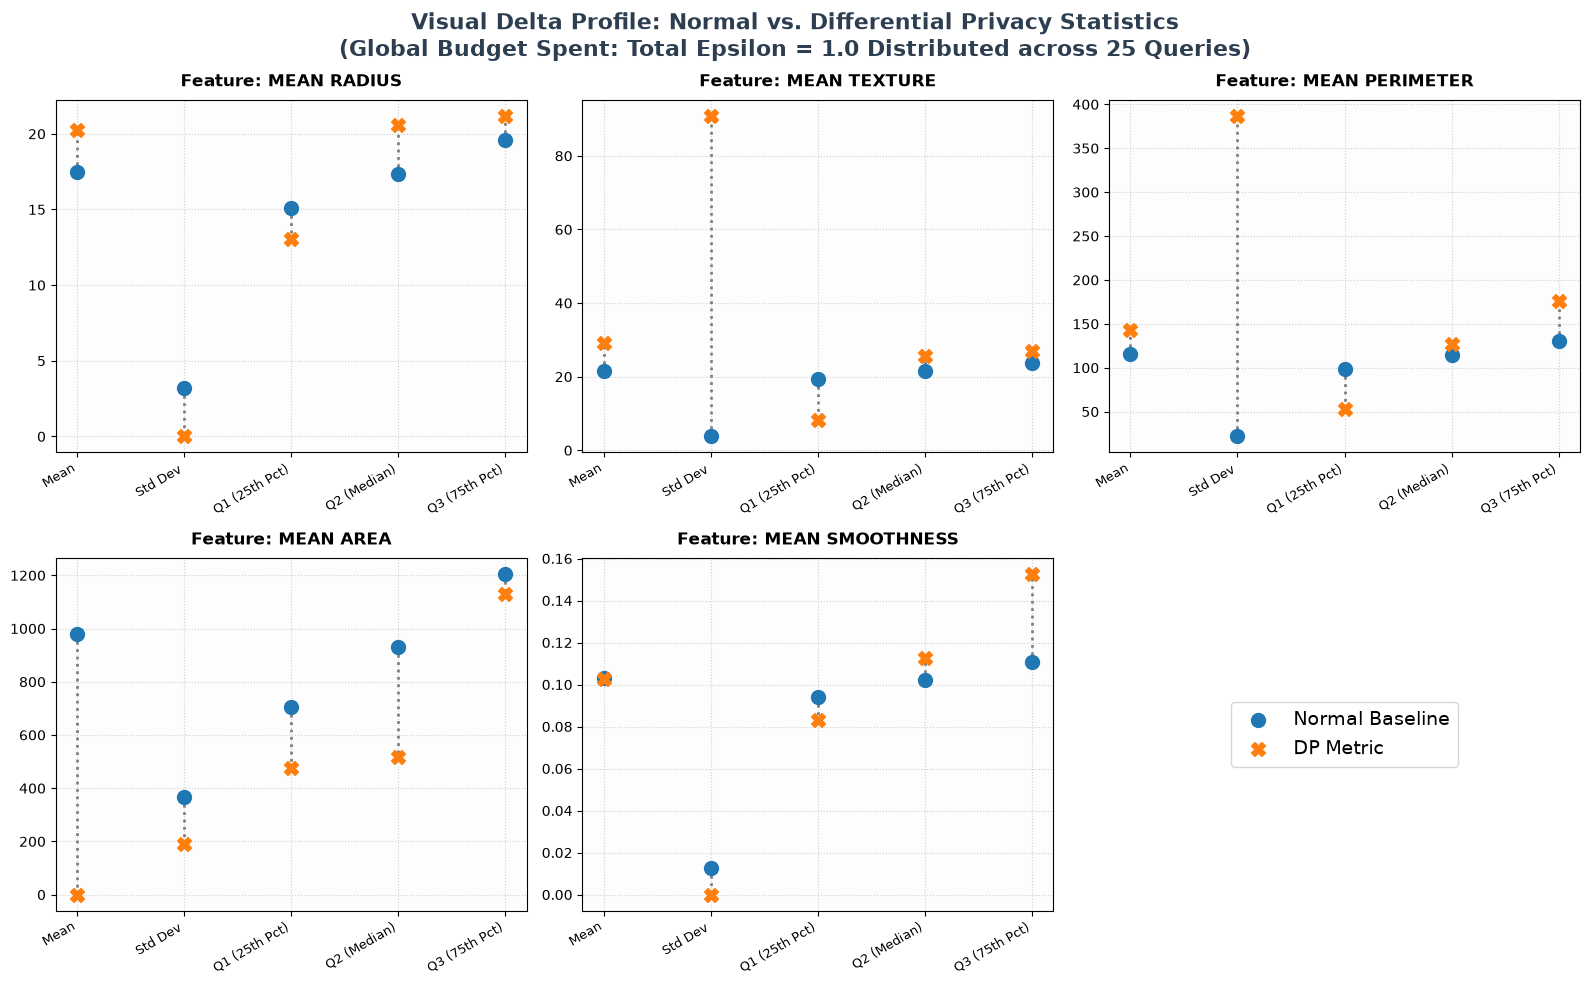

In [81]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten() # Flatten the 2D grid into a 1D list to loop through easily

for i, col in enumerate(features):
    ax = axes[i]
    
    # Extract values for the current feature
    true_vals = base_results[col]
    dp_vals = dp_results[col]
    
    x_indices = np.arange(len(stat_query))
    
    # 1. Plot the True Base Stats as solid Blue dots
    ax.scatter(x_indices, true_vals, color='#1f77b4', s=100, zorder=3, label='Normal Baseline')
    
    # 2. Plot the DP Stats as orange cross markers
    ax.scatter(x_indices, dp_vals, color='#ff7f0e', marker='X', s=100, zorder=3, label=f'DP Metric')
    
    # 3. Draw a vertical line connecting them (the "Error/Delta Bar")
    for idx in x_indices:
        ax.vlines(idx, true_vals[idx], dp_vals[idx], colors='gray', linestyles='dotted', lw=2)
        
    # Formatting each sub-graph
    ax.set_title(f"Feature: {col.upper()}", fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks(x_indices)
    ax.set_xticklabels(stat_query, rotation=30, ha='right', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Add a subtle background shading to separate columns visually
    ax.set_facecolor('#fdfdfd')

# Handle the 6th empty subplot slot (since we only have 5 features)
axes[5].axis('off')
# Add a single master legend inside the empty space
axes[5].legend(*axes[0].get_legend_handles_labels(), loc='center', fontsize=14, frameon=True)

# Global layout styling
plt.suptitle(f"Visual Delta Profile: Normal vs. Differential Privacy Statistics\n(Global Budget Spent: Total Epsilon = {total_epsilon} Distributed across 25 Queries)", 
             fontsize=16, fontweight='bold', color='#2c3e50')
plt.tight_layout()
plt.show()